In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
run_name = 'frac01'
SAVE_DIR = f'/content/drive/MyDrive/grokking/{run_name}/'   # create folder, prepend to both paths
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# config of the transformer
p=113 # the divisor in mod p. prime so it makes the modular structure clean, the model cant find shortcuts
d_model= 128 # the width of the residual stream
n_heads= 4 # 4 parrallel heads
d_head= d_model//n_heads # 32, width of each head
d_mlp = 4 * d_model # 4*d_model is convention. its the hidden width of the mlp block. the 128 vector gets expanded to 512 and then project back down to 128
n_ctx = 3 # sequence length, exactly 3 tokens which are x y =
d_vocab = p + 1 # number of distinct tokens
lr = 1e-3 # learning rate
wd = 1.0 # weight decay. absurdly high, its the pressure that makes grokking happen fast
frac_train = 0.1 # what percentage of the data we use for training
seed = 0 # makes the run repoducible
# num_epochs = 200
num_epochs = 100000
betas=(0.9, 0.98) # adam optimizer betas from grokking paper

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import random

# create each pair
def create_data(frac_train, num, seed = 0):
  pairs = [(i,j) for i in range(num) for j in range(num)]

  random.seed(seed)
  random.shuffle(pairs)
  div = int(frac_train * len(pairs))

  return pairs[:div], pairs[div:]

train, test = create_data(frac_train, p, seed)
print(len(train), len(test))

1276 11493


In [ ]:
import torch

def to_tokens(pairs, p):
  inputs = []
  labels = []
  for pair in pairs:
    inputs.append((pair[0], pair[1], p))
    labels.append((pair[0] + pair[1]) % p)

  inputs = torch.tensor(inputs)
  labels = torch.tensor(labels)

  return inputs, labels

train_inputs, train_labels = to_tokens(train, p)
test_inputs, test_labels = to_tokens(test, p)

train_inputs = train_inputs.to(device)
train_labels = train_labels.to(device)
test_inputs = test_inputs.to(device)
test_labels = test_labels.to(device)

print(len(train_inputs), len(train_labels))
print(train_inputs.shape, train_labels.shape)   # [3830, 3], [3830]
print(train_inputs.dtype)                        # torch.int64
print(train_inputs[0], train_labels[0])          # (x, y, 113) and (x+y)%113

1276 1276
torch.Size([1276, 3]) torch.Size([1276])
torch.int64
tensor([ 18,  34, 113], device='cuda:0') tensor(52, device='cuda:0')


In [ ]:
import torch.nn as nn
import numpy as np

class Transformer(nn.Module):
  def __init__(self, d_vocab, d_model, n_ctx):
    super().__init__()
    self.W_E = nn.Parameter(torch.randn(d_vocab, d_model) / np.sqrt(d_model))
    self.W_pos = nn.Parameter(torch.randn(n_ctx, d_model) / np.sqrt(d_model))
    self.W_U = nn.Parameter(torch.randn(d_model, d_vocab) / np.sqrt(d_model))
    self.attn = Attention(d_model, n_heads, d_head, n_ctx)
    self.mlp = MLP(d_model, d_mlp)

  def forward(self, tokens):
    embed = self.W_E[tokens]
    x = embed + self.W_pos
    x = x + self.attn(x)
    x = x + self.mlp(x)
    logits = x @ self.W_U
    # print(logits.shape)
    return logits


# print(out.shape)   # torch.Size([3830, 3, 128])
# print(train_inputs.shape)
# print(model.W_E.shape)
# print(model.W_pos.shape)

In [ ]:
from einops import rearrange

class Attention(nn.Module):
  def __init__(self, d_model, n_heads, d_head, n_ctx):
    super().__init__()
    self.n_heads = n_heads
    self.d_head = d_head
    self.W_Q = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.W_K = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.W_V = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.W_O = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.register_buffer('mask', torch.tril(torch.ones(n_ctx, n_ctx)))

  def forward(self, resid):
    q = rearrange(resid @ self.W_Q, 'n s (h d) -> n h s d', h = self.n_heads)
    k = rearrange(resid @ self.W_K, 'n s (h d) -> n h s d', h = self.n_heads)
    v = rearrange(resid @ self.W_V, 'n s (h d) -> n h s d', h = self.n_heads)

    scores = (q @ k.transpose(2,3)) / np.sqrt(self.d_head)
    scores = scores.masked_fill(self.mask == 0, -1e10)
    pattern = torch.softmax(scores, dim=-1)

    z = rearrange(pattern @ v, 'n h s d -> n s (h d)', h = self.n_heads)
    o = z @ self.W_O

    return o

# attention = Attention(d_model, n_heads, d_head, n_ctx)
# outa = attention(out)
# print(outa.shape)



In [ ]:
class MLP(nn.Module):
  def __init__(self, d_model, d_mlp):
    super().__init__()
    self.W_in = nn.Parameter(torch.randn(d_model, d_mlp) / np.sqrt(d_model))
    self.W_out = nn.Parameter(torch.randn(d_mlp, d_model) / np.sqrt(d_mlp))
    self.b_in = nn.Parameter(torch.zeros(d_mlp))
    self.b_out = nn.Parameter(torch.zeros(d_model))

  def forward(self, x):
    z = x @ self.W_in + self.b_in
    h = torch.relu(z)
    return h @ self.W_out + self.b_out

# mlp = MLP(d_model, d_mlp)
# outm = mlp(outa)

In [ ]:
# model = Transformer(d_vocab, d_model, n_ctx)
# logits = model(train_inputs)
# print(logits.shape)

# sliced_logits = logits[:,-1,:]

# loss = torch.nn.functional.cross_entropy(sliced_logits, train_labels)

# print(loss)


In [ ]:
# start
torch.manual_seed(seed)
model = Transformer(d_vocab, d_model, n_ctx)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas)

train_losses = []
test_losses = []
start_epoch = 0

In [ ]:
# resume
model = Transformer(d_vocab, d_model, n_ctx).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas)
ckpt = torch.load(SAVE_DIR + 'checkpoint.pt')
model.load_state_dict(ckpt['model'])
optimizer.load_state_dict(ckpt['optimizer'])
start_epoch = ckpt['epoch'] + 1
train_losses = ckpt['train_losses']
test_losses = ckpt['test_losses']

In [ ]:
# resume from baseline post-grok checkpoint (lr-drop experiment)
model = Transformer(d_vocab, d_model, n_ctx).to(device)
ckpt = torch.load('/content/drive/MyDrive/grokking/baseline/ckpt_20000.pt', map_location=device)
model.load_state_dict(ckpt['model'])
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas)
start_epoch = 20000
train_losses = []
test_losses = []
print(run_name, lr, wd, SAVE_DIR)

lr-drop 0.0001 1.0 /content/drive/MyDrive/grokking/lr-drop/


In [ ]:
# training loop
torch.save({'train': train_losses, 'test': test_losses}, SAVE_DIR + 'losses.pt')
for i in range(start_epoch, num_epochs):
  logits = model(train_inputs)
  sliced_logits = logits[:,-1,:]
  loss = torch.nn.functional.cross_entropy(sliced_logits, train_labels)

  if i % 10 == 0:
    with torch.no_grad():
      test_logits = model(test_inputs)
      test_sliced_logits = test_logits[:,-1,:]
      test_loss = torch.nn.functional.cross_entropy(test_sliced_logits, test_labels)
      train_losses.append(loss.item())
      test_losses.append(test_loss.item())
      if i % 500 == 0:
        print('train loss at', i, loss)
        print('test loss at', i, test_loss)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if i % 100 == 0:
    ckpt = {
      'model': model.state_dict(),
      'optimizer': optimizer.state_dict(),
      'epoch': i,
      'train_losses': train_losses,
      'test_losses': test_losses,
    }
    try:
        torch.save(ckpt, SAVE_DIR + 'checkpoint.pt')
        if i % 2000 == 0:
            torch.save({'model': model.state_dict()}, SAVE_DIR + f'ckpt_{i}.pt')
    except Exception as e:
        print(f'save failed at {i}: {e}')

train loss at 50000 tensor(9.1107e-07, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 50000 tensor(52.2461, device='cuda:0')
train loss at 50500 tensor(0.0106, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 50500 tensor(22.4507, device='cuda:0')
train loss at 51000 tensor(0.0002, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 51000 tensor(34.8718, device='cuda:0')
train loss at 51500 tensor(1.0160e-06, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 51500 tensor(51.5215, device='cuda:0')
train loss at 52000 tensor(0.0088, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 52000 tensor(23.3592, device='cuda:0')
train loss at 52500 tensor(0.0002, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 52500 tensor(34.1760, device='cuda:0')
train loss at 53000 tensor(1.1818e-06, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 53000 tensor(51.1457, device='cuda:0')
train loss at 53500 tensor(0.0045, device='cuda:0', grad_fn=<Nll

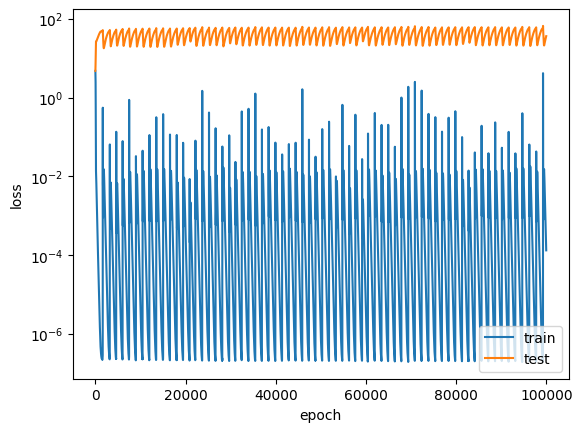

In [ ]:
import matplotlib.pyplot as plt

epochs = range(0, num_epochs, 10)
# epochs = range(start_epoch, start_epoch + len(train_losses) * 10, 10) # post drop
plt.plot(epochs, train_losses, label='train')
plt.plot(epochs, test_losses, label='test')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
torch.save({'train': train_losses, 'test': test_losses}, SAVE_DIR + 'losses.pt')
plt.savefig(SAVE_DIR + 'baseline_curves.png', dpi=150)
plt.show()